### Test gradient calculation
Notebook to test the calculation of the gradient 
\begin{equation}
\frac{df}{d\xi} = -\frac{\nabla \psi}{|\nabla \psi|} \cdot \nabla f
\end{equation}
is correct, by using an analytic function for $f$. In this case we choose
\begin{equation}
f = x^2 + \mu^2.
\end{equation}
First, we generate $\psi(x,\mu)$, then interpolate the value of $\nabla \psi$ along the chosen contour.

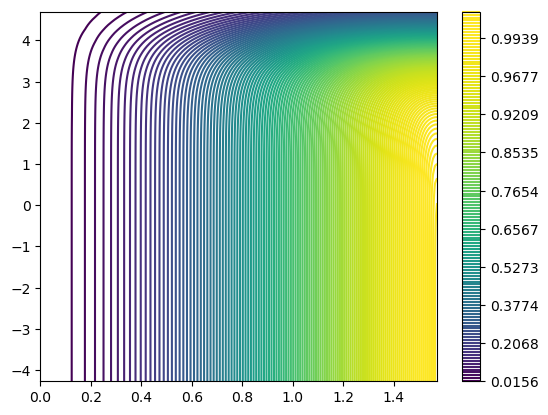

In [2]:
# generate grids:
def grid_gen(xmin, xmax, mumin, mumax, nx, nmu, LOGSCALEX, DX1,X1LOW):
    # Generate polar coordinate arrays

    if(LOGSCALEX == 1):
        ii = np.linspace(0,nx-1,nx)
        x = np.exp(-X1LOW)*(np.exp(ii*DX1)-1.0)
    else:
        x = np.linspace(xmin,xmax,nx)
        
    mu = np.linspace(mumin,mumax,nmu)

    # Generate polar grid
    mu_grid, x_grid = np.meshgrid(mu, x)

    # Output
    return mu_grid, x_grid

def psi_gen(xgrid, mugrid, n_contours,aratio,dx,dmu,alpha):
        
    psi_grid = (1.0-mugrid*mugrid)/(xgrid/aratio+alpha)
    
    mu_levels = np.empty(n_contours)
    
    for i in range(n_contours):
        contour_mesh_value = (n_contours - i)/(n_contours+1.)/dmu
        mu_levels[i] = contour_mesh_value*dmu
        
    psi_levels = (1-mu_levels*mu_levels)/alpha

    return psi_grid, psi_levels

import numpy as np
from matplotlib import pyplot as plt

XMIN = 0
XMAX = 50000.0
MUMIN = 0.0
MUMAX = 1.0
X1LOW = 8.0
LOGSCALEX = 1
nr = 128
nth = 128
alpha_ratio = 1
n_contours = 127
x0 = 0.538
R_star = 1e4
aratio = R_star/x0

X1 = np.log(np.exp(X1LOW)*XMAX + 1.0)
DX1 = X1/(nr - 1.0)

if(LOGSCALEX == 1):
    dx = DX1
else:
    dx = (XMAX-XMIN)/(nr-1.0)
dmu = np.abs(MUMAX-MUMIN)/(nth-1.0)


mugrid, xgrid = grid_gen(XMIN,XMAX,MUMIN,MUMAX,nr,nth,LOGSCALEX,DX1,X1LOW)
psi_grid, psi_levels = psi_gen(xgrid, mugrid, n_contours,aratio,dx,dmu, alpha_ratio)

fig,ax = plt.subplots()
cb=ax.contour(np.arccos(mugrid[1:,:]),np.log10(xgrid[1:,:]),psi_grid[1:,:],levels=psi_levels)
fig.colorbar(cb)
plt.show()


In [34]:
def f_func(x,mu):
    return x**2 + mu**2

def dfdxi_func(x,mu,aratio):
    return 2.*np.sqrt(1- mu**2)/np.sqrt(1 + 3*mu**2)*(2*mu**2*np.sqrt(1 - mu**2)/(x + aratio) - x)

def dxi_func(x0,x1,mu0,mu1,aratio):
    x_avg = 0.5*(x0 + x1)
    mu_avg = 0.5*(mu0 + mu1)
    return np.sqrt((x1 - x0)**2 + (x_avg + aratio)**2 / (1 - mu_avg**2) * (mu1 - mu0)**2)

Now import contour array generator:

In [8]:
from contourpy import contour_generator

def gen_contour_array(xgrid, mugrid, psi_grid, psi_levels):

    cont_gen = contour_generator(mugrid, xgrid, psi_grid, quad_as_tri=True)
    lines_arr_0 = np.array(cont_gen.lines(psi_levels[0]))[0]
    contour_array = np.hstack((lines_arr_0,np.reshape(np.zeros(len(lines_arr_0)),(-1,1))))

    for index in range(1,len(psi_levels)):
        # check if cont_gen.lines() returns an empty array:
        if(len(cont_gen.lines(psi_levels[index])[0]) == 0):
            continue
        else:
            lines = np.array(cont_gen.lines(psi_levels[index])[0])
            contour_array = np.append(contour_array, np.hstack((lines, np.reshape(index*np.ones(len(lines)), (-1,1)))), axis=0)

    # remove any contour coordinates below some limit xlim:
    # contour_array_output = contour_array[((contour_array[:,1] < 1.e-10))|(contour_array[:,1] > 1.e-3)]

    return contour_array

contour_array = gen_contour_array(xgrid,mugrid,psi_grid,psi_levels)

def gen_s(mucoords,xcoords,alpha_ratio,aratio):
    avg_x = 0.5*(xcoords[1:] + xcoords[:-1])
    avg_mu = 0.5*(mucoords[1:] + mucoords[:-1])
    dxs = xcoords[1:] - xcoords[:-1]
    dmus = (avg_x + alpha_ratio*aratio)/np.sqrt((1.0 - avg_mu*avg_mu))*(mucoords[1:] - mucoords[:-1])
    ds = np.sqrt(dxs*dxs + dmus*dmus)
    s = np.append(0, np.cumsum(ds))
    return s 
    
def interpolate_function(data, mu, x, dmu, dx, LOGSCALEX, X1LOW):

    # Calc Nx, Nmu:
    nx = data.shape[0]
    nmu = data.shape[1]

    # Find base point, and distance of (mu,x) from the base point
    if(LOGSCALEX == 1):
        x1 = np.log(x + np.exp(-X1LOW)) + X1LOW
    else:
        x1 = x

    if((np.abs(x1/dx - np.rint(x1/dx)) > 1e-10) & (np.abs(x1/dx - np.rint(x1/dx)) < 1e-4)):
        ix = int(np.rint(x1/dx))
        xs=0.0
    else:
        ix = int(np.floor(x1/dx))
        xs = x1/dx - ix

    imu = int(np.floor(mu/dmu))
    mus = mu/dmu - imu

    if((ix < nx - 1) & (imu < nmu - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu+1]
        data2 = data[ix+1, imu]
        data3 = data[ix+1, imu+1]
        
    if((ix == nx - 1) & (imu < nmu - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu+1]
        data2 = 0
        data3 = 0

    if((imu == nmu - 1) & (ix < nx - 1)):
        data0 = data[ix, imu]
        data1 = 0
        data2 = data[ix+1, imu]
        data3 = 0

    if((imu == nmu - 1) & (ix == nx - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu]
        data2 = data[ix, imu]
        data3 = data[ix, imu]

    interpolant = xs*mus*data3 + (1-mus)*xs*data2 + mus*(1-xs)*data1 + (1-xs)*(1-mus)*data0

    return interpolant

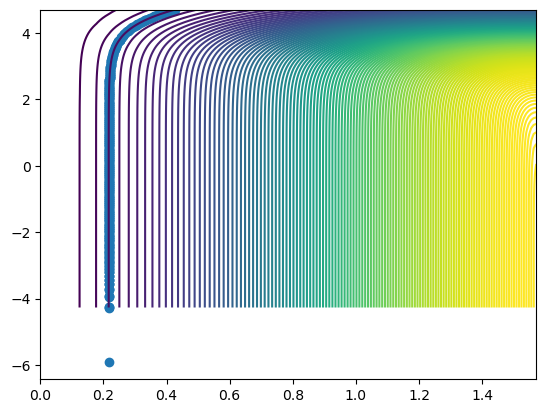

In [15]:
# Generate (r, theta) coordinates for the selected flux surface *psi* given by variable *index*.
index = 2
mucoords = contour_array[contour_array[:, 2] == index][:, 0]
xcoords = contour_array[contour_array[:, 2] == index][:, 1]
fig,ax = plt.subplots()
ax.contour(np.arccos(mugrid[1:,:]),np.log10(xgrid[1:,:]),psi_grid[1:,:],levels=psi_levels)
ax.scatter(np.arccos(mucoords[1:]),np.log10(xcoords[1:]))
plt.show()

s = gen_s(mucoords, xcoords,alpha_ratio,aratio)
gradx_grid, gradmu_grid = np.gradient(psi_grid,xgrid[:,0],mugrid[0,:])
gradx = np.array([interpolate_function(gradx_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])
gradmu = np.array([interpolate_function(gradmu_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])

grad_psi_interp = np.array([np.sqrt(gradx[i]*gradx[i] + (1.0 - mucoords[i]*mucoords[i])/(xcoords[i] + alpha_ratio*aratio)/(xcoords[i] + alpha_ratio*aratio)*gradmu[i]*gradmu[i]) for i in range(len(s))])


Now import adjacent point generator:

In [58]:
from shapely.geometry import LineString
import shapely

def gen_adjacent_point(contour_array,mu_b,x_b, cont_number, point_number, gradx, gradmu, which_side, aratio, xmin, xmax, mumin, mumax, xg, mug, zg, zlevels, tag_string, plot_option):

    # extract contour coordinates of given flux line
    mucoords_b = contour_array[contour_array[:,2]==cont_number][:,0]
    xcoords_b = contour_array[contour_array[:,2]==cont_number][:,1]

    # extract coordinates of desired adjacent contour:
    mucoords_a = contour_array[contour_array[:,2]==cont_number+which_side][:,0]
    xcoords_a = contour_array[contour_array[:,2]==cont_number+which_side][:,1]

    # Construct normal curve to flux line to find intersection
    vector_mu_component = gradmu
    vector_x_component = gradx
    vector_magnitude = np.sqrt(vector_mu_component**2 + vector_x_component**2)
    vector_mu_vals = np.linspace(0, 1, 100)

    vector_gradient = vector_x_component / vector_mu_component
    vector_proj = vector_gradient*vector_mu_vals + (x_b - vector_gradient*mu_b)

    # Find where normal vector intersects adjacent contour curve using shapely package
    vector_linestring = np.c_[vector_mu_vals, vector_proj]
    ls1 = LineString(np.c_[mucoords_a, xcoords_a])
    ls2 = LineString(np.c_[vector_mu_vals, vector_proj])

    if(shapely.intersects(ls1,ls2)):
        # find intersection
        points = shapely.intersection(ls1,ls2)
        if(type(points).__name__=='Point'): # if the line intersects at a single point, the ls1 object will have a single entry
            mu_int, x_int = points.x, points.y
        elif(type(points).__name__=='MultiPoint'): # if the line intersects at two points, ls1 will be a multipoint object
            multipoint = points.geoms
            # find closest point in the case where the lines intersect multiple times. choose the point with the smallest distance between x values
            mp_delta_prev = 1e10 # pick a large number
            k = 0
            for i in range(len(multipoint)):
                mp_delta = np.abs(np.abs(multipoint[i].x - mu_b)) # calculate distance between i-th multipoint and point mu_b on original surface
                if(mp_delta < mp_delta_prev): # if the distance is closer, choose this point
                    k = i
                    mp_delta_prev = mp_delta
                else:
                    continue
            mu_int,x_int = multipoint[k].x, multipoint[k].y
    else:
        # return nearest value
        x_int = xcoords_a[np.abs(x_b - xcoords_a).argmin()]
        mu_int = mucoords_a[np.abs(x_b - xcoords_a).argmin()]
    # optional plotting
    plotting = plot_option
    # plotting = "on"
    if(((plotting == "on") | (plotting == 1)) & (point_number%1==0)):
        fig,ax = plt.subplots(figsize=(9,7)) 

        ax.contour(np.arccos(mug[1:,:]),np.log10(xg[1:,:]),zg[1:,:], levels = zlevels, alpha = 0.2)
        ax.scatter(np.arccos(mu_b),np.log10(x_b), c='green', label=r"$(x_j, \mu_j)$")
        ax.quiver(np.arccos(mu_b),np.log10(x_b), np.arccos(mu_b + vector_mu_component) - np.arccos(mu_b), np.log10((x_b + vector_x_component)/(x_b)),angles='xy',scale_units='xy',alpha=0.2,label='normal vector')
        ax.scatter(np.arccos(mucoords_a),np.log10(xcoords_a), alpha = 0.1, label=r"$\psi_{i-1}$")
        ax.scatter(np.arccos(mucoords_b),np.log10(xcoords_b), alpha = 0.1, label=r"$\psi_{i}$")
        ax.plot(np.arccos(vector_linestring[:,0]), np.log10(vector_linestring[:,1]), '.-r', alpha = 0.3)
        ax.scatter(np.arccos(mu_int),np.log10(x_int), c='red', label=r"$(x_j, \mu_j)^{(i-1)}$")

        plt.legend()
        ax.set(title=f"i={point_number}",xlabel=r"$\cos\theta$",ylabel=r"$\log_{10} \tilde{x}$")
        plt.show()

    return mu_int, x_int, vector_linestring, mucoords_a,xcoords_a


/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_64942/2088984166.py:59: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.arccos(mucoords_a),np.log10(xcoords_a), alpha = 0.1, label=r"$\psi_{i-1}$")
/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_64942/2088984166.py:60: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.arccos(mucoords_b),np.log10(xcoords_b), alpha = 0.1, label=r"$\psi_{i}$")


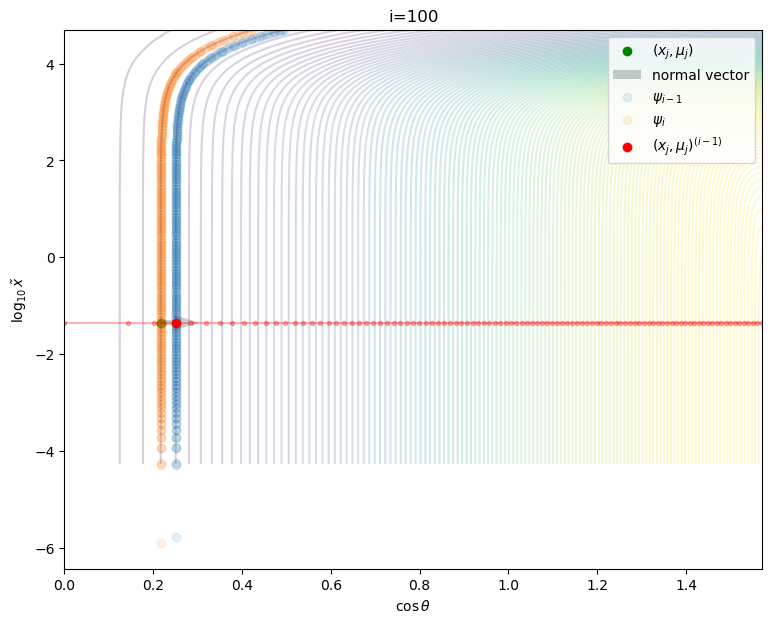

In [87]:
j = 100
mu_int,x_int,_,mucoords_a,xcoords_a = gen_adjacent_point(contour_array, mucoords[j],xcoords[j], index,j,gradx[j],gradmu[j],1,aratio,XMIN,XMAX,MUMIN,MUMAX,xgrid,mugrid,psi_grid,psi_levels,1,1)
dmu_int_original = mucoords[j] - mu_int
# fig,ax = plt.subplots()
# ax.contour(np.arccos(mugrid[1:,:]),np.log10(xgrid[1:,:]), psi_grid[1:,:],levels=psi_levels,alpha = 0.2)
# ax.scatter(np.arccos(mucoords[1:]),np.log10(xcoords[1:]), alpha = 0.3, label=r"$\psi_{i}$")
# ax.scatter(np.arccos(mucoords_a[1:]),np.log10(xcoords_a[1:]), alpha = 0.1, label=r"$\psi_{i-1}$")
# ax.legend()
# plt.show()

0.9765617197596614 0.9687489593267996 0.007812760432861832
f0 = 0.9556476843041332
f1 = 0.955628153169738
dxi = 0.8634852678672411
dfdxi estimated = -2.261895497460425e-05
dfdxi_0 = -9.73090e-03, dfdxi_1 = -9.73302e-03
f_1 estimated = 0.9472451980550757


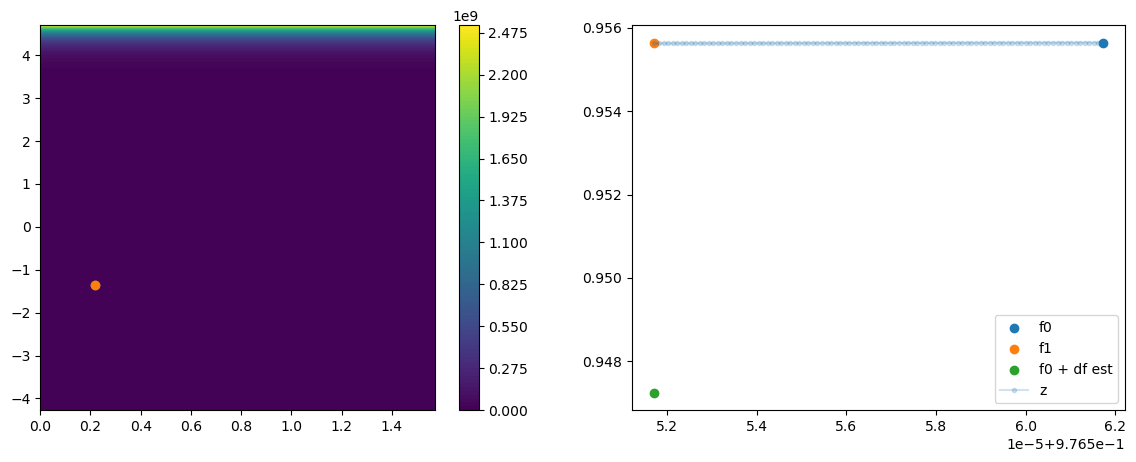

In [93]:
print(mucoords[j], mu_int, dmu_int_original)
x_int = xcoords[j]
mu_int = mucoords[j] - 1.e-5
f_0 = f_func(xcoords[j],mucoords[j])
f_1 = f_func(x_int,mu_int)
f_grid = f_func(xgrid,mugrid)
dxi = dxi_func(xcoords[j], x_int, mucoords[j], mu_int,aratio)

dfdxi_est = (f_1 - f_0)/dxi
dfdxi_0 = dfdxi_func(xcoords[j], mucoords[j], aratio)
dfdxi_1 = dfdxi_func(x_int,mu_int,aratio)

df_calc = dfdxi_0 * dxi
df_est = dfdxi_est * dxi

print(f"f0 = {f_0}\nf1 = {f_1}\ndxi = {dxi}\ndfdxi estimated = {dfdxi_est}\ndfdxi_0 = {dfdxi_0:0.5e}, dfdxi_1 = {dfdxi_1:0.5e}\nf_1 estimated = {f_0 + df_calc}")

mu_plot = np.linspace(mu_int, mucoords[j], 100) 
zplot = xcoords[j]**2 + mu_plot**2

zmin = np.min(f_grid)
zmax = np.max(f_grid)

fig,(ax,ax2) = plt.subplots(1,2,figsize = (14,5))
cb = ax.contourf(np.arccos(mugrid[1:,:]), np.log10(xgrid[1:,:]), f_grid[1:,:], levels=100)
ax.scatter(np.arccos(mucoords[j]), np.log10(xcoords[j]))
ax.scatter(np.arccos(mu_int), np.log10(x_int))
fig.colorbar(cb)
ax2.scatter(mucoords[j],f_0,label='f0')
ax2.scatter(mu_int, f_1, label='f1')
ax2.scatter(mu_int, f_0 + df_calc, label='f0 + df est')
ax2.plot(mu_plot, zplot, '.-',alpha = 0.2, label = "z")
ax2.legend()
# ax2.set(ylim=[zmin,zmax])
plt.show()